## Data Preparation

In [25]:
import torch
import numpy
import math

words = open('../data/indonesian_names.txt', 'r').read().splitlines()

words[:4]

['aan', 'abdul', 'abdullah', 'abidin']

In [63]:
N = torch.zeros((27, 27), dtype=torch.int32)

chars = sorted(set(''.join(words)))

stoi = {s:i+1 for i,s in enumerate(chars)}; stoi['.'] = 0
itos = {s:i for i, s in stoi.items()}

# stoi['a'] = 1
# itos[1] = 'a'

In [57]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        x1 = stoi[ch1]
        x2 = stoi[ch2]

        N[x1, x2] += 1
    

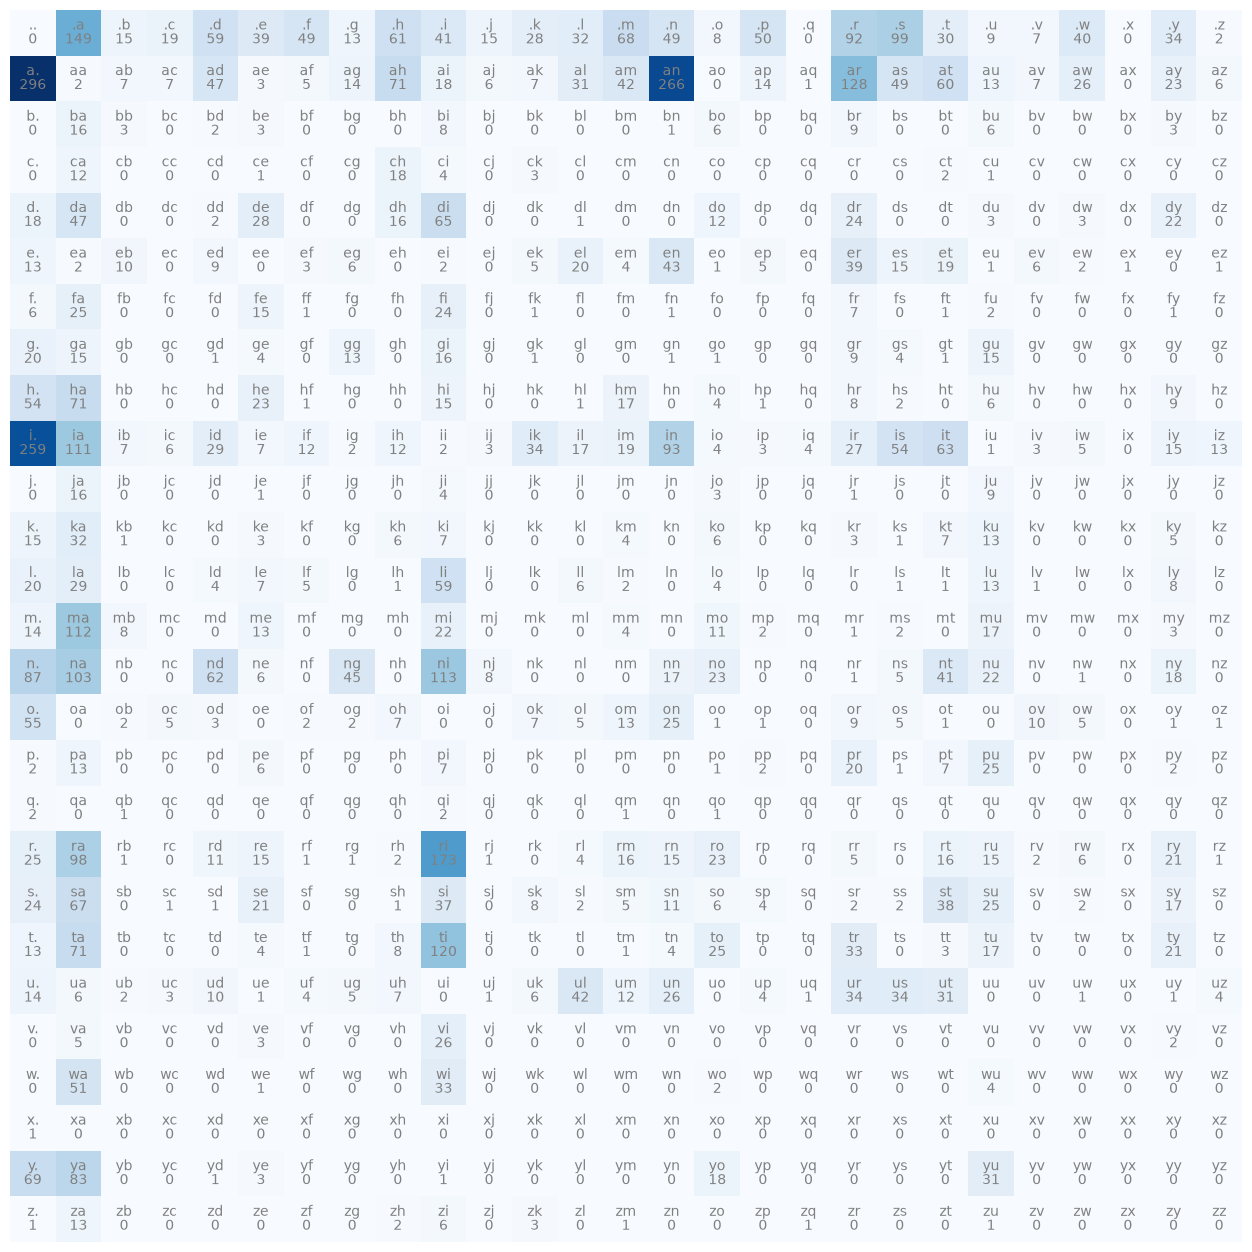

In [60]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")

plt.axis('off');

## Statistical Method
1. prepare the torch for probability matrix
2. sort alphabetically to map it
3. add two frequency to get the distribution
4. normalize and smoothing
5. test it out
6. calculate the MLE loss 

## Neural Network Method
1. split into feature and target
2. turn feature into OHE 
3. alternative approach: directly access W[row]
4. train it (logits, softmax, loss, backward, update)
5. test it out